In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset import and predictors selection

In [3]:
gdf = gpd.read_file("/content/drive/MyDrive/CCGEO_folder/morpho.geojson")

gdf.loc[gdf["lip"] > 1, "lip"] = 1

label_col = "lip"
predictors = ["Slope_mean",
              "HorizontalCurvature_mean",
              "VerticalCurvature_mean",
              "MeanCurvature_mean"]

# Basic cleaning
df = gdf.dropna(subset=predictors + [label_col]).copy()

X = df[predictors]
y = df[label_col].astype(int)

### Model selection

In [4]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
    ))
])

### Calibration

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.2504 - loss: 0.7683 - val_accuracy: 0.4074 - val_loss: 0.7100
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4616 - loss: 0.7009 - val_accuracy: 0.7222 - val_loss: 0.6572
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7933 - loss: 0.6432 - val_accuracy: 0.8519 - val_loss: 0.6101
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8836 - loss: 0.5895 - val_accuracy: 0.9074 - val_loss: 0.5687
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9078 - loss: 0.5462 - val_accuracy: 0.9074 - val_loss: 0.5320
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9201 - loss: 0.5061 - val_accuracy: 0.9074 - val_loss: 0.4986
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9236 - loss: 0.4645 - val_accuracy: 0.9074 - val_loss: 0.4682
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9236 - loss: 0.4449 - val_accuracy: 0.9074 - val_loss:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


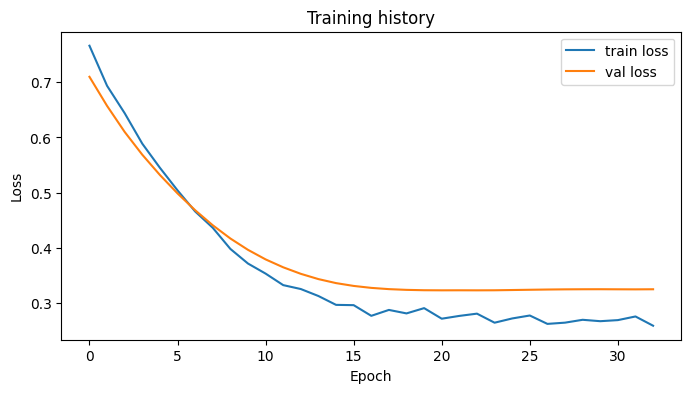

In [5]:

# --- Replaced with TensorFlow / Keras model ---
# This cell replaces the previous sklearn MLP classifier.
# It expects `X` and `y` to already exist in the notebook (numpy arrays or pandas DataFrame / Series).
# If `X` and `y` are pandas objects, the code will convert them automatically.

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Ensure X and y exist; try to coerce pandas -> numpy if necessary
try:
    X  # reference to check existence
except NameError:
    raise NameError('X not defined in notebook. Make sure you have created X and y before running this cell.')

# Convert pandas to numpy if needed
if hasattr(X, 'values'):
    X_np = X.values.astype('float32')
else:
    X_np = np.asarray(X, dtype='float32')

if hasattr(y, 'values'):
    y_np = y.values
else:
    y_np = np.asarray(y)

# For binary classification ensure shape (n,)
y_np = y_np.ravel().astype('float32')

# Train/test split (keeps things reproducible)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42, stratify=y_np if len(np.unique(y_np))>1 else None)

# Scale features (very important for NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build a small feed-forward network appropriate for bivariate/tabular data
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')   # sigmoid for binary classification
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping for convenience
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[es], verbose=1)

# Predictions and probabilities on the whole dataset (if you prefer original X, transform first)
y_proba_test = model.predict(X_test).ravel()
y_pred_test = (y_proba_test >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_proba_test) if len(np.unique(y_test))==2 else None
print(f"Test accuracy: {acc:.4f}")
if auc is not None:
    print(f"Test ROC AUC: {auc:.4f}")
print('\\nClassification report:')
print(classification_report(y_test, y_pred_test))

# Save results back to variables used earlier
y_proba = np.concatenate([model.predict(scaler.transform(X_np)).ravel()])  # probabilities on full X (useful for notebooks expecting y_proba)
y_pred = (y_proba >= 0.5).astype(int)

# Optional: plot training curves
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training history')
plt.show()

# If the problem is bivariate (2 features), plot the decision boundary
if X_np.shape[1] == 2:
    xx_min, xx_max = X_np[:,0].min() - 1, X_np[:,0].max() + 1
    yy_min, yy_max = X_np[:,1].min() - 1, X_np[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 200), np.linspace(yy_min, yy_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    proba_grid = model.predict(grid_scaled).ravel()
    Z = proba_grid.reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, Z, levels=50, alpha=0.8)
    scatter = plt.scatter(X_np[:,0], X_np[:,1], c=y_np, edgecolor='k', s=40)
    plt.xlabel('feature 0')
    plt.ylabel('feature 1')
    plt.title('Decision boundary (probability contour)')
    plt.colorbar(scatter, label='class')
    plt.show()



### Results evaluation

In [6]:
print("Confusion matrix:\n", confusion_matrix(y, y_pred))
print("ROC AUC:", roc_auc_score(y, y_proba))


Confusion matrix:
 [[307   0]
 [ 28   0]]
ROC AUC: 0.6192415076779897


### Cross-validation

In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    clf,
    X, y,
    cv=cv,
    scoring=["roc_auc"],
)

print("ROC AUC:", scores["test_roc_auc"].mean())

ROC AUC: 0.39781362007168464


### Plot ROC

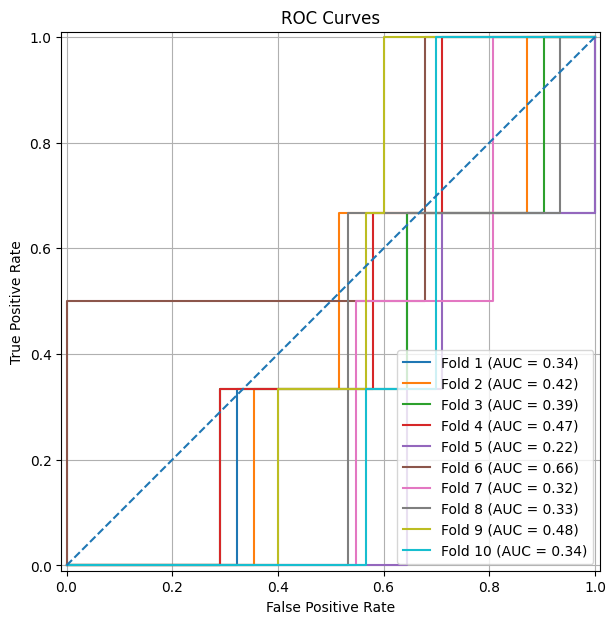

In [8]:

fig, ax = plt.subplots(figsize=(7, 7))

aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf.fit(X_train, y_train)

    y_proba = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    aucs.append(auc)

    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=f"Fold {fold}",
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)

plt.show()

